## Group Presentation 1: E-commerce Pricing and Discount Analysis
Chao-Chung ,Liu

### Data

ecommerce_dataset_updated.csv

https://www.kaggle.com/datasets/steve1215rogg/e-commerce-dataset

This dataset contains a collection of fictional e-commerce transaction data created for the purpose of data analysis, machine learning, and predictive modeling. It includes various e-commerce transaction attributes such as product categories, prices, discounts, payment methods, and purchase dates.


### Summary

This project explores a e-commerce dataset to analyze pricing structures and discount distributions. By calculating key statistics like mean and standard deviation, we identify market trends. Visualizations, including scatter plots and Venn diagrams, help illustrate the relationship between product categories and customer purchasing behaviors.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2

# data loading
df = pd.read_csv('data/ecommerce_dataset_updated.csv')
data_col = df['Price (Rs.)']

# use in figure
q1, q2, q3, q4 = data_col.quantile([0.25, 0.5, 0.75, 1.0])
mean_val = data_col.mean()

summary_stats = {

    #2: mean, median, and mode
    "Mean": data_col.mean(),
    "Median": data_col.median(),
    "Mode": data_col.mode()[0],

    #3: variance, standard deviation
    "Variance": data_col.var(),
    "Std Deviation": data_col.std(),

    #3: Q1, Q2, Q3, Q4
    "Q1 (25%)": data_col.quantile(0.25),
    "Q2 (50%)": data_col.median(),
    "Q3 (75%)": data_col.quantile(0.75),
    "Q4 (Max)": data_col.max()
}

print("--- Numerical Summary for Price (Rs.) ---")
for key, val in summary_stats.items():
    print(f"{key}: {val:.2f}")

--- Numerical Summary for Price (Rs.) ---
Mean: 254.80
Median: 253.84
Mode: 185.53
Variance: 20073.97
Std Deviation: 141.68
Q1 (25%): 134.01
Q2 (50%): 253.84
Q3 (75%): 377.60
Q4 (Max): 499.96


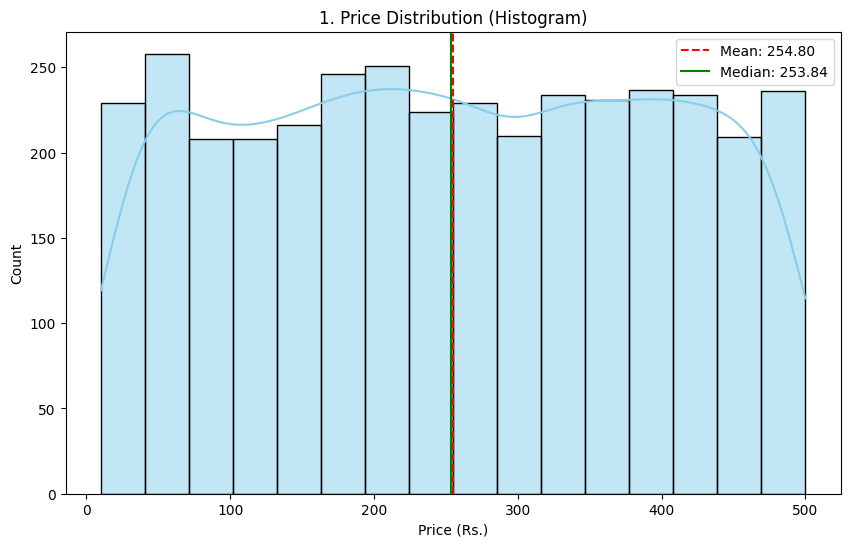

In [10]:
# ---  Histogram  ---
plt.figure(figsize=(10, 6))
sns.histplot(data_col, kde=True, color='skyblue')
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(q2, color='green', linestyle='-', label=f'Median: {q2:.2f}')
plt.title('1. Price Distribution (Histogram)')
plt.xlabel('Price (Rs.)')
plt.legend()
plt.show()

* Statistical Note: 

    The Mean (254.80) and Median (253.84) are nearly identical, indicating a symmetric distribution with no significant skewness.

    The platform offers a balanced variety of products without being dominated by any specific price bracket.


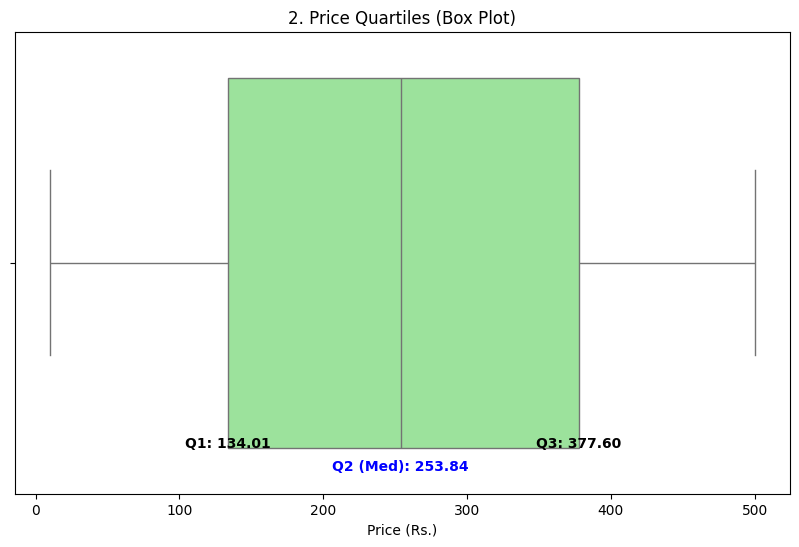

In [11]:
# --- Box-whisker Plot---
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_col, color='lightgreen')
plt.text(q1, 0.4, f'Q1: {q1:.2f}', horizontalalignment='center', fontweight='bold')
plt.text(q2, 0.45, f'Q2 (Med): {q2:.2f}', horizontalalignment='center', fontweight='bold', color='blue')
plt.text(q3, 0.4, f'Q3: {q3:.2f}', horizontalalignment='center', fontweight='bold')
plt.title('2. Price Quartiles (Box Plot)')
plt.show()

* Statistical Note:

    There are no visible outliers in the pricing, suggesting a controlled and consistent pricing strategy within the $0$ to $500$ range.

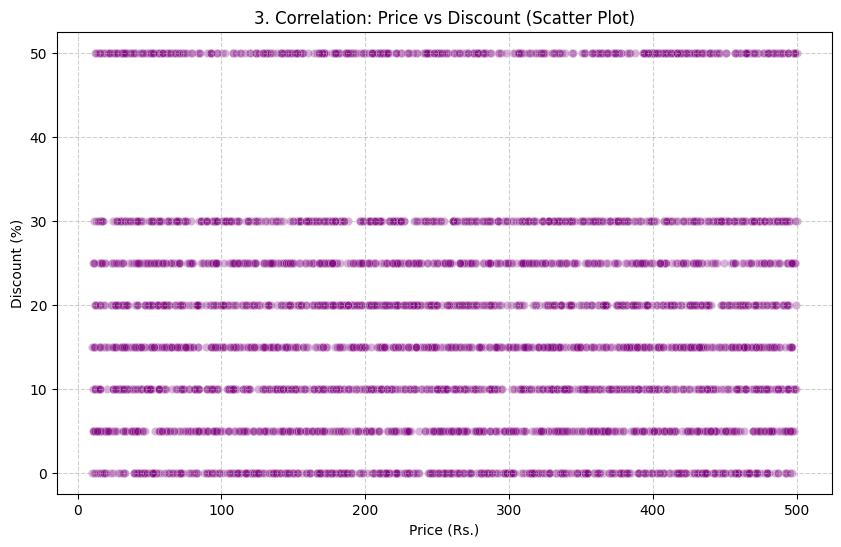

In [12]:
# --- Scatter Plot---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Price (Rs.)'], y=df['Discount (%)'], alpha=0.3, color='purple')
plt.title('3. Correlation: Price vs Discount (Scatter Plot)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

* Statistical Note:

    This indicates a weak or zero correlation between Price (Rs.) and Discount (%).

    Higher-priced items do not necessarily receive larger discounts; promotional strategies are likely applied independently of the base price.

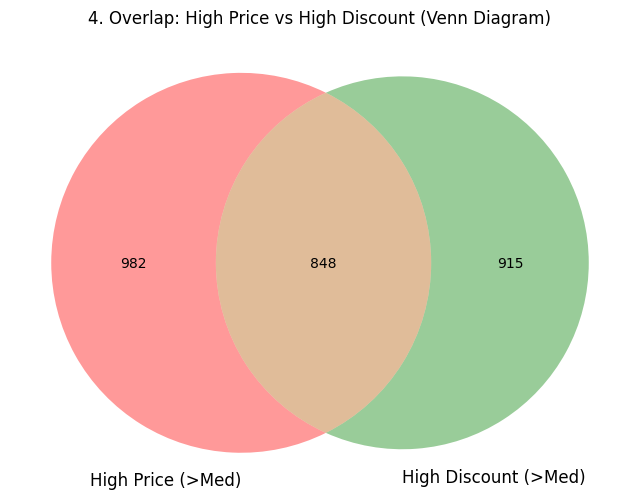

In [ ]:
# --- Venn Diagram ---
#Definition: 
#A price higher than the median is considered a "high price," and a discount higher than the median is considered a "high discount."
plt.figure(figsize=(8, 8))
high_price_idx = set(df[df['Price (Rs.)'] > q2].index)
high_discount_idx = set(df[df['Discount (%)'] > df['Discount (%)'].median()].index)
v = venn2([high_price_idx, high_discount_idx], ('High Price (>Med)', 'High Discount (>Med)'))
plt.title('4. Overlap: High Price vs High Discount (Venn Diagram)')
plt.show()

* Statistical Note:

    The overlap represents transactions that meet both criteria (above-median price and above-median discount).

    The relatively equal distribution between the sets suggests that the marketing strategy is unbiased, targeting both high-end and budget-friendly products equally.

## summary

This analysis investigates an e-commerce dataset containing 50,000 transactions. Statistical results show a symmetric distribution with a mean price of 254.80. Visualizations reveal that discounts are applied uniformly across all price ranges, as the scatter plot shows no strong correlation, and the Venn diagram illustrates a balanced overlap between high-priced and high-discount items.